In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [2]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat','Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

In [3]:
transform = transforms.ToTensor()

In [5]:
train_data = datasets.FashionMNIST(
    root = '/Users/judah/Machine learning and Advanced data methods/Lab Materials/block 1 week 2',
    train = True,
    download =False,
    transform = transform
)


test_data = datasets.FashionMNIST(
    root = '/Users/judah/Machine learning and Advanced data methods/Lab Materials/block 1 week 2',
    train = False,
    download = False,
    transform = transform
)

In [6]:
train_data.data.shape

torch.Size([60000, 28, 28])

In [7]:
from random import shuffle


train_loader = DataLoader(train_data, batch_size=64, shuffle=True, num_workers=0)

test_loader = DataLoader(test_data, batch_size=64, shuffle=True, num_workers=0)

In [8]:
sample_image, sample_label = next(iter(train_loader))
print(sample_image.shape)

torch.Size([64, 1, 28, 28])


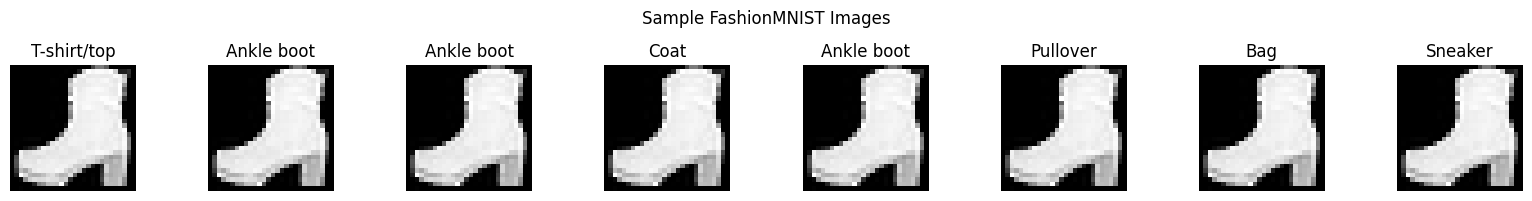

Saved sample images to exercise_part1_samples.png



In [9]:
from matplotlib import axes
from matplotlib.pyplot import imshow


fig, axes = plt.subplots(1, 8, figsize=(16, 2))

for i in range(8):
    axes[i].imshow(sample_image[1].squeeze(), cmap='gray')
    axes[i].set_title(class_names[sample_label[i]])
    axes[i].axis('off')
plt.suptitle("Sample FashionMNIST Images")
plt.tight_layout()
plt.savefig('exercise_part1_samples.png', dpi=100)
# plt.close()
plt.show()
print("Saved sample images to exercise_part1_samples.png")
print()

In [23]:
# CNN ARCHITECTURE

class CNN(nn.Module):
    def __init__(self) -> None:
        super(CNN, self).__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels = 1,out_channels = 16,
            kernel_size = 3,
            stride = 1,
            padding = 1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(16, 32, 3, 1, 1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
        )
        self.conv3 = nn.Sequential(
            nn.Conv2d(32, 64, 3, 1, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 2),
        )

        self.dropout = nn.Dropout(0.5)
        self.out = nn.Linear(64 * 3 * 3, 10)


    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = x.view(x.size(0), -1)
        x = self.dropout(x)
        output = self.out(x)
        return output, x

In [24]:
cnn = CNN()

In [25]:
loss_func = nn.CrossEntropyLoss()
optimizer = optim.Adam(cnn.parameters(), lr = 0.0001)

In [26]:
# training function

num_epochs = 20
def train(num_epochs, cnn, train_loader):
    cnn.train()
    total_step = len(train_loader)
    train_losses = []

    for epoch in range(num_epochs):
        correct = 0
        total = 0
        running_loss = 0

        for i, (images, labels) in enumerate(train_loader):
            output = cnn(images)[0]
            loss = loss_func(output, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            pred_y = torch.max(output, 1)[1]
            correct += (pred_y == labels).sum().item()
            total += labels.size(0)
            running_loss += loss.item()

        epoch_loss = running_loss/total_step
        epoch_acc = correct/total
        train_losses.append(epoch_loss)

        print(f'Epoch [{epoch+1}/{num_epochs}] | Train Loss: {epoch_loss:.4} | Train Accuracy:{epoch_acc:.4}')
        
    return train_losses

In [27]:
train_losses = train(num_epochs, cnn, train_loader)

Epoch [1/20] | Train Loss: 0.8773 | Train Accuracy:0.6968
Epoch [2/20] | Train Loss: 0.5236 | Train Accuracy:0.8134
Epoch [3/20] | Train Loss: 0.444 | Train Accuracy:0.8421
Epoch [4/20] | Train Loss: 0.4017 | Train Accuracy:0.8568
Epoch [5/20] | Train Loss: 0.3728 | Train Accuracy:0.8665
Epoch [6/20] | Train Loss: 0.3531 | Train Accuracy:0.8745
Epoch [7/20] | Train Loss: 0.3383 | Train Accuracy:0.8781
Epoch [8/20] | Train Loss: 0.3269 | Train Accuracy:0.8835
Epoch [9/20] | Train Loss: 0.3169 | Train Accuracy:0.8868
Epoch [10/20] | Train Loss: 0.3067 | Train Accuracy:0.8899
Epoch [11/20] | Train Loss: 0.2991 | Train Accuracy:0.892
Epoch [12/20] | Train Loss: 0.293 | Train Accuracy:0.8938
Epoch [13/20] | Train Loss: 0.2865 | Train Accuracy:0.8951
Epoch [14/20] | Train Loss: 0.2803 | Train Accuracy:0.8989
Epoch [15/20] | Train Loss: 0.2756 | Train Accuracy:0.9014
Epoch [16/20] | Train Loss: 0.2706 | Train Accuracy:0.9019
Epoch [17/20] | Train Loss: 0.2701 | Train Accuracy:0.9017
Epoch [18

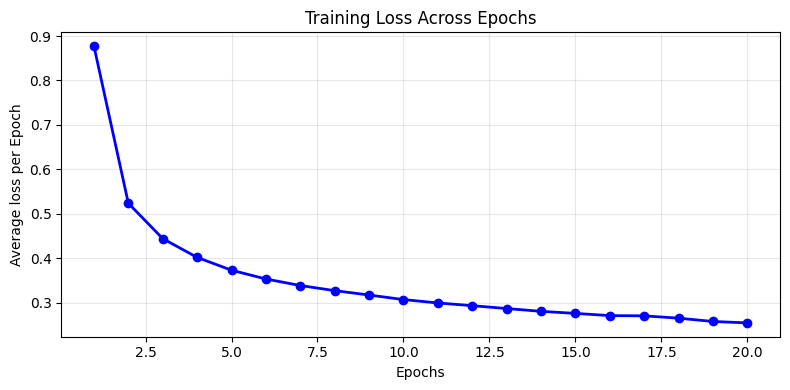

Saved loss curve to exercise_part5_loss_curve.png


In [28]:
#Plot loss curve

plt.figure(figsize=(8, 4))

plt.plot(range(1, num_epochs + 1), train_losses, 'b-o', linewidth =2)
plt.xlabel('Epochs')
plt.ylabel('Average loss per Epoch')
plt.title('Training Loss Across Epochs')
plt.grid(True, alpha = 0.3)
plt.tight_layout()
plt.show()
plt.savefig('exercise_part5_loss_curve.png', dpi=100)
plt.close()
print("Saved loss curve to exercise_part5_loss_curve.png")



In [29]:
def test():
    cnn.eval()
    with torch.no_grad():
        correct = 0
        total = 0
        for images, labels in test_loader:
            test_output, last_layer = cnn(images)
            pred_y = torch.max(test_output, 1)[1].data.squeeze()
            correct += (pred_y == labels).sum().item()
            total += labels.size(0)

        accuracy = correct / total
        print(f'Test Accuracy: {accuracy:.4f}')
test()


Test Accuracy: 0.9025


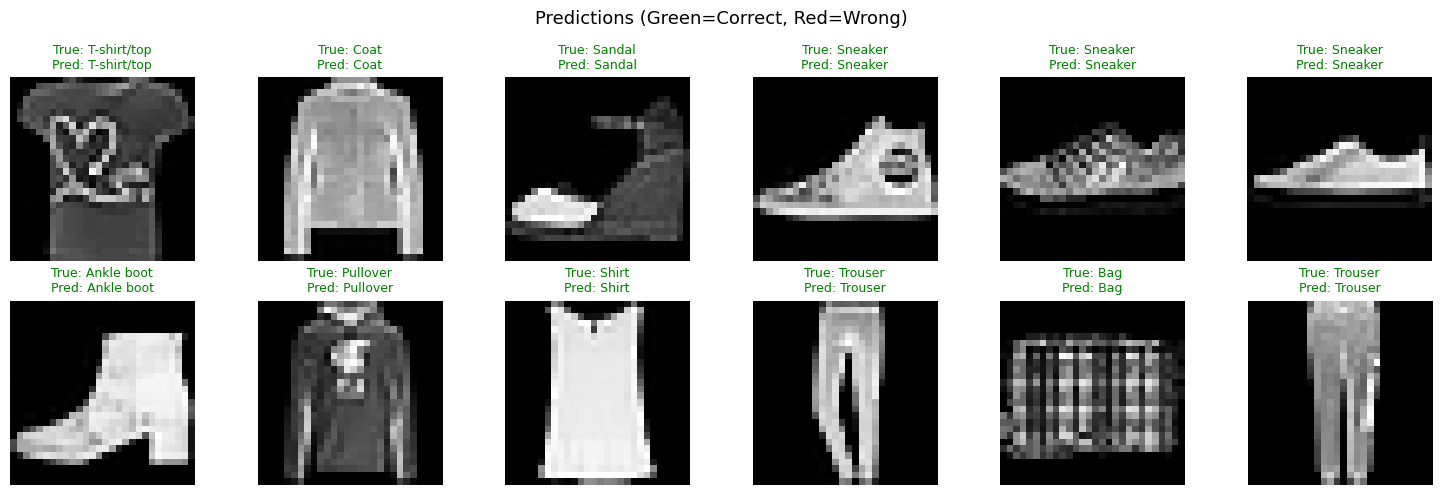

Saved predictions to exercise_part7_predictions.png


In [30]:
# Visualize accuracy

test_images, test_labels = next(iter(test_loader))
with torch.no_grad():
    test_outputs = cnn(test_images)[0]
    test_preds = torch.max(test_outputs, 1)[1]

fig, axes = plt.subplots(2, 6, figsize=(15, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(test_images[i].squeeze(), cmap='gray')
    true_label = class_names[test_labels[i]]
    pred_label = class_names[test_preds[i]]
    color = 'green' if test_labels[i] == test_preds[i] else 'red'
    ax.set_title(f"True: {true_label}\nPred: {pred_label}",
                 color=color, fontsize=9)
    ax.axis('off')
plt.suptitle("Predictions (Green=Correct, Red=Wrong)", fontsize=13)
plt.tight_layout()
plt.show()
plt.savefig('exercise_part7_predictions.png', dpi=100)
plt.close()
print("Saved predictions to exercise_part7_predictions.png")


In [ ]:
# accuracy per class

from sklearn.metrics import confusion_matrix
import seaborn as sns

cnn.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        outputs = cnn(images)[0]
        preds = torch.max(outputs, 1)[1]
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

for i, name in enumerate(class_names):
    mask = [j for j, l in enumerate(all_labels) if l == i]
    correct = sum(all_preds[j] == i for j in mask)
    print(f'{name}: {correct/len(mask):.4f}')

T-shirt/top: 0.8820
Trouser: 0.9780
Pullover: 0.9000
Dress: 0.8930
Coat: 0.8380
Sandal: 0.9740
Shirt: 0.6490
Sneaker: 0.9770
Bag: 0.9770
Ankle boot: 0.9570


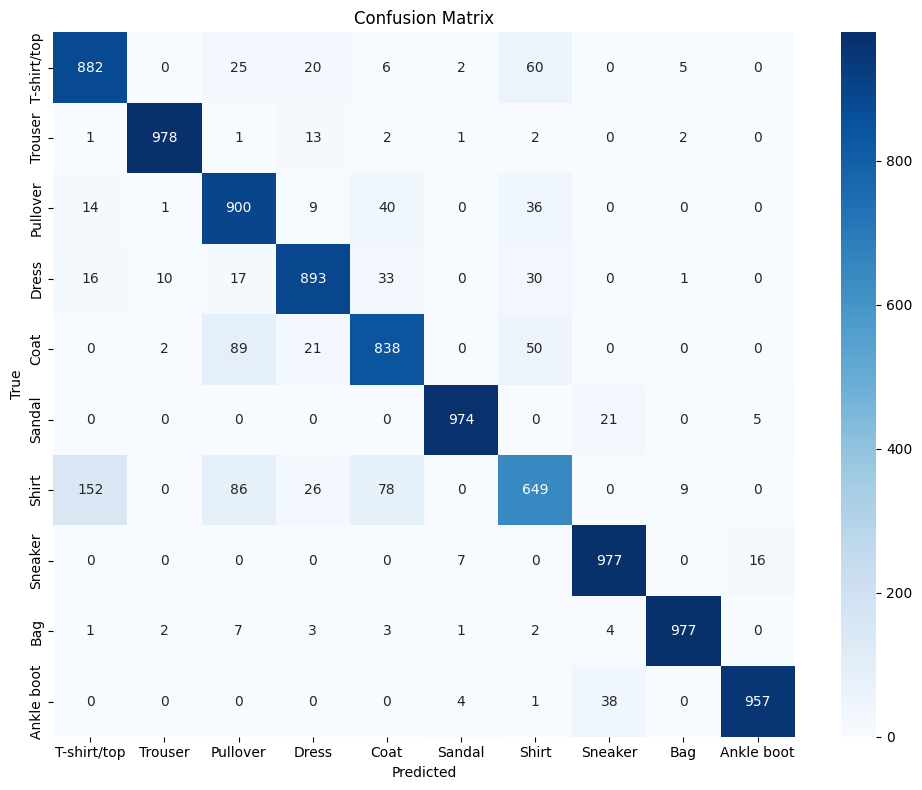

In [32]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig('exercise_confusion_matrix.png', dpi=100)
plt.show()